# Chapter 4 &mdash; Two-Dimensional Cellular Automata

On a 2-D toroidal lattice a CA state is an image, and its rule is a
**2-D convolution kernel** &mdash; the exact machinery of image
processing. From a single seed, additive rules unfold intricate,
symmetric *mandalas*; and one non-additive rule gives the most
famous CA of all, Conway's **Game of Life**.

In [1]:
# Setup: put the cadyn package on the path and enable inline figures.
# If you installed the package (`pip install -e .` from the repo root),
# the sys.path line is unnecessary.
import sys, pathlib
repo = pathlib.Path.cwd()
for _ in range(4):                      # find the repo root from anywhere
    if (repo / "cadyn").is_dir():
        break
    repo = repo.parent
sys.path.insert(0, str(repo))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
from cadyn import ca2d

## A mandala from a single seed

The von Neumann kernel sums a cell with its four orthogonal
neighbors (mod 256). One nonzero cell, grown for 100 generations,
produces this:

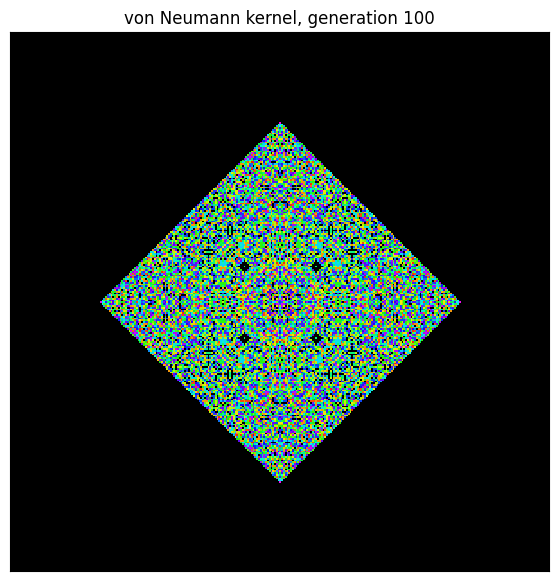

In [3]:
final, snaps = ca2d.run_additive(ca2d.single_seed(300),
                                 ca2d.KERNEL_VON_NEUMANN,
                                 k=256, generations=100,
                                 sample_at=(100,))
ca2d.show_state(snaps[100], k=256, zero_color="black",
                title="von Neumann kernel, generation 100")
plt.show()

## The kernels really are image filters

The same convolution machinery, applied *once* (without the mod-$k$
step), is ordinary image processing. Here a Laplacian kernel
extracts edges and a smoothing kernel blurs &mdash; iterated
smoothing is discrete diffusion (the heat equation).

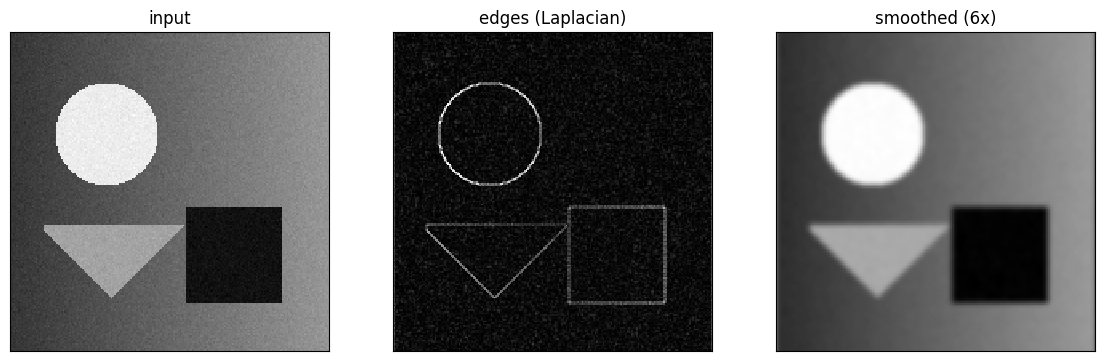

In [4]:
img = ca2d.demo_image(200)
edges = ca2d.filter_image(img, ca2d.EDGE_KERNEL)
smooth = img
for _ in range(6):
    smooth = ca2d.filter_image(smooth, ca2d.BLUR_KERNEL)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
ca2d.show_gray(img, ax=axes[0], title="input")
ca2d.show_gray(np.abs(edges), ax=axes[1], title="edges (Laplacian)")
ca2d.show_gray(smooth, ax=axes[2], title="smoothed (6x)")
plt.show()

## Conway's Game of Life

The rules: a dead cell with exactly 3 live neighbors is **born**; a
live cell with 2 or 3 neighbors **survives**; otherwise it dies. We
color live cells by **age** (cerise = newborn ... violet =
ancient).

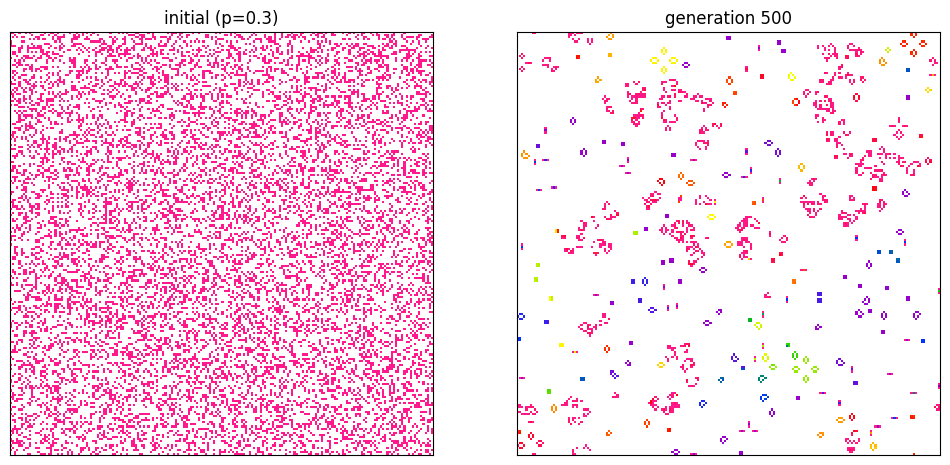

In [5]:
alive0 = ca2d.random_life(200, p=0.3, rng=np.random.default_rng(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ca2d.show_life(alive0.astype(int), ax=axes[0], title="initial (p=0.3)")
alive, age = ca2d.run_life(alive0, 500)
ca2d.show_life(age, ax=axes[1], title="generation 500")
plt.show()

### A bestiary: the glider and the Gosper gun

Life has a rich zoo of patterns. A **glider** is a small shape that
translates diagonally, returning to itself shifted by $(1,1)$ every
4 generations. The **Gosper glider gun** endlessly emits gliders
&mdash; the discovery that first proved Life patterns can grow
without bound.

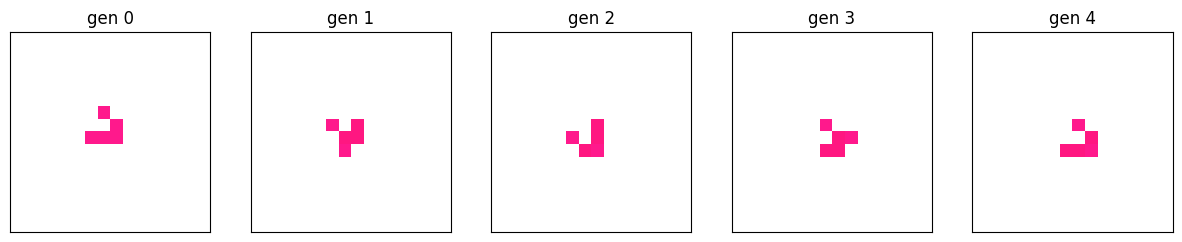

glider returns to itself shifted by (1,1) after 4 gens: True


In [6]:
# glider: watch it move
g = ca2d.pattern_grid(ca2d.GLIDER, 16)
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
a, age = g.astype(bool), g.astype(int)
for ax, gen in zip(axes, range(5)):
    if gen:
        a, age = ca2d.run_life(a, 1)
    ca2d.show_life(age, ax=ax, title=f"gen {gen}")
plt.show()

# verify the period-4 diagonal translation
a4, _ = ca2d.run_life(g.astype(bool), 4)
shifted = np.roll(np.roll(g.astype(bool), 1, 0), 1, 1)
print("glider returns to itself shifted by (1,1) after 4 gens:",
      np.array_equal(a4, shifted))

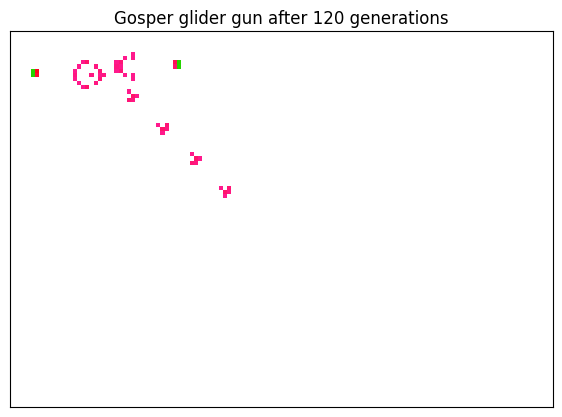

In [7]:
gun = ca2d.pattern_grid(ca2d.GOSPER_GLIDER_GUN, 90, 130, top=5, left=5)
_, age = ca2d.run_life(gun, 120)
ca2d.show_life(age, title="Gosper glider gun after 120 generations")
plt.show()

## A number-theoretic rule: Euler's totient

Non-additive rules need not be Life-like. This one sums Euler's
totient $\varphi$ over the Moore neighborhood (mod 256), producing
yet another mandala from a single seed.

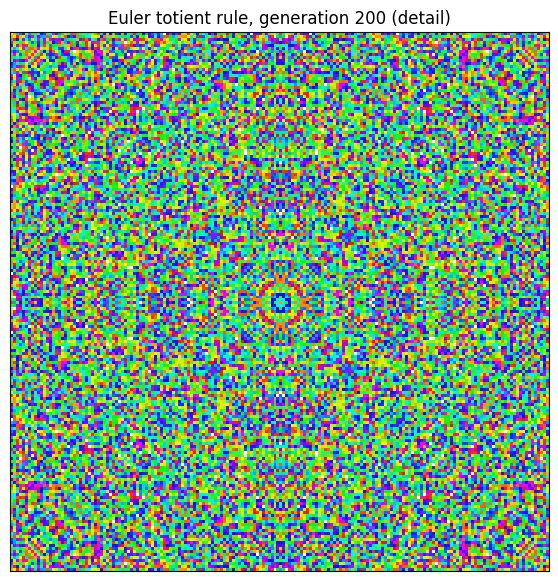

In [8]:
state = ca2d.run_rule(ca2d.single_seed(300),
                      ca2d.totient_step(256), 200)
ca2d.show_state(state, k=256, crop=180,
                title="Euler totient rule, generation 200 (detail)")
plt.show()

## Your turn

1. Swap in the signed kernel `ca2d.KERNEL_4_3` and grow a mandala
   from a single seed.
2. Seed Life with your own patterns via
   `ca2d.pattern_grid(list_of_(row,col), n)` &mdash; try a
   *blinker* `[(1,0),(1,1),(1,2)]` or an *r-pentomino*.
3. Start Life from `ca2d.seed_grid` of many seeds and watch the
   interactions. (Animations are especially fun &mdash; export
   frames with `show_life` inside a loop.)